In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Parte 1/4 

Implementar a distribuição Binomial pelo método ingênuo

(array([3.200e+01, 2.430e+02, 1.047e+03, 2.502e+03, 3.097e+03, 2.150e+03,
        7.630e+02, 1.480e+02, 1.600e+01, 2.000e+00]),
 array([32. , 36.1, 40.2, 44.3, 48.4, 52.5, 56.6, 60.7, 64.8, 68.9, 73. ]),
 <BarContainer object of 10 artists>)

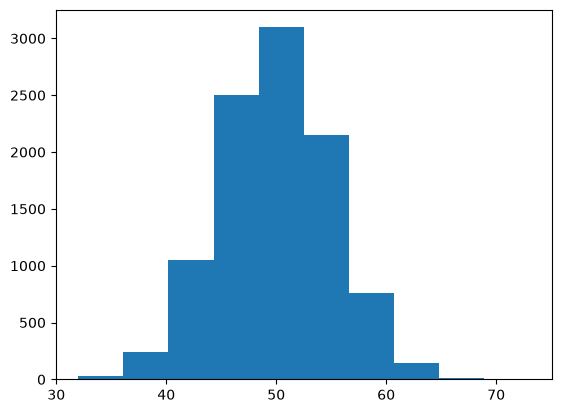

In [3]:
n = 100
p = 0.5
M = 10000

def bin_ingenuo(M, n, p):
  amostra = []
  for i in range(M):
    uniforme = np.random.uniform(0,1,n)
    binomial = np.sum(uniforme < p)
    amostra.append(binomial)
  return amostra

amostraa = bin_ingenuo(M,n,p)
plt.hist(amostraa)

# Parte 2/4

Implementar a distribuição Binomial pelo método recursivo

(array([   7.,   58.,  404., 1337., 2729., 3027., 1771.,  547.,  104.,
          16.]),
 array([30. , 33.9, 37.8, 41.7, 45.6, 49.5, 53.4, 57.3, 61.2, 65.1, 69. ]),
 <BarContainer object of 10 artists>)

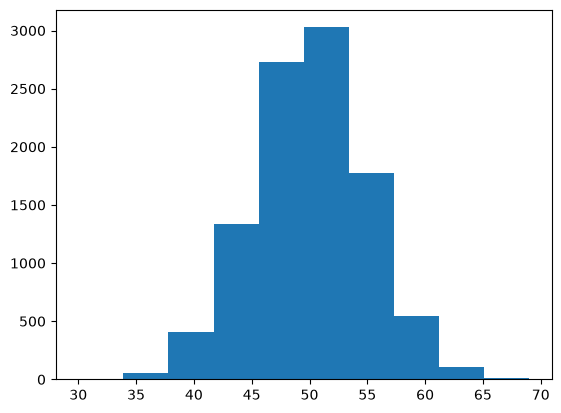

In [4]:
def bin_recursiva(M,n,p):
    amostra_r = []
    for j in range(M):
        u = np.random.uniform(0,1)
        i=0
        p_i = (1-p)**n
        f=p_i
        x=0
        while u > f:
            p_imais1 = ((n-i)/(i+1)) * (p/(1-p)) *p_i
            i = i+1
            p_i = p_imais1
            f=f+p_i
            x=i
        amostra_r.append(x)
    return amostra_r

amostraaaa = bin_recursiva(M,n,p)
plt.hist(amostraaaa)

# Parte 3/4

Calculando os tempos de execução para cada implementação usando a função np.linspace e time.time()

In [5]:
M = 1000      
N = 100
p = np.linspace(0.1, 0.9, 2)
n = np.linspace(10, 100, 2).astype(int)

tempo_p_i = []
tempo_p_r = []

for j in n:
    for i in p:
        tempos_i = []
        tempos_r = []
        
        for a in range(N):
            inicio = time.time()
            bin_ingenuo(M, j, i)
            tempos_i.append(time.time() - inicio)
            
            inicio = time.time()
            bin_recursiva(M, j, i)
            tempos_r.append(time.time() - inicio)
            
        tempo_p_i.append(np.mean(tempos_i))
        tempo_p_r.append(np.mean(tempos_r))

print(np.mean(tempo_p_i))
print(np.mean(tempo_p_r))

0.011630389094352723
0.021113094687461854


# Parte 4/4
Tempo de execução para diferentes valores de p onde podemos ver que o método ingênuo ganha por muito devido à independência em relacional ao valor de p.

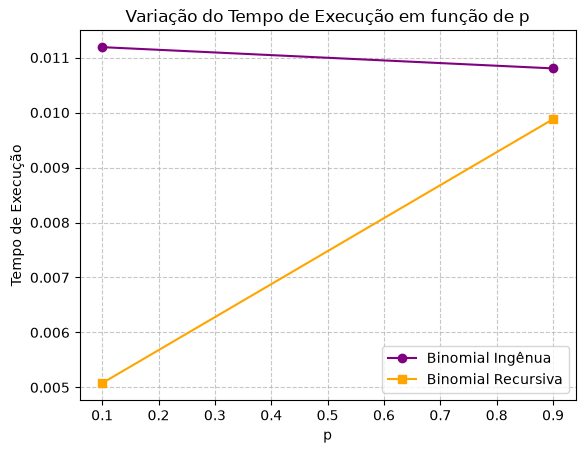

In [6]:
tempo_i_n = tempo_p_i[:len(p)]
tempo_r_n = tempo_p_r[:len(p)]

plt.plot(p, tempo_i_n, label='Binomial Ingênua', marker='o', color='purple')
plt.plot(p, tempo_r_n, label='Binomial Recursiva', marker='s', color='orange')
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Variação do Tempo de Execução em função de p')
plt.xlabel('p')
plt.ylabel('Tempo de Execução')
plt.legend()